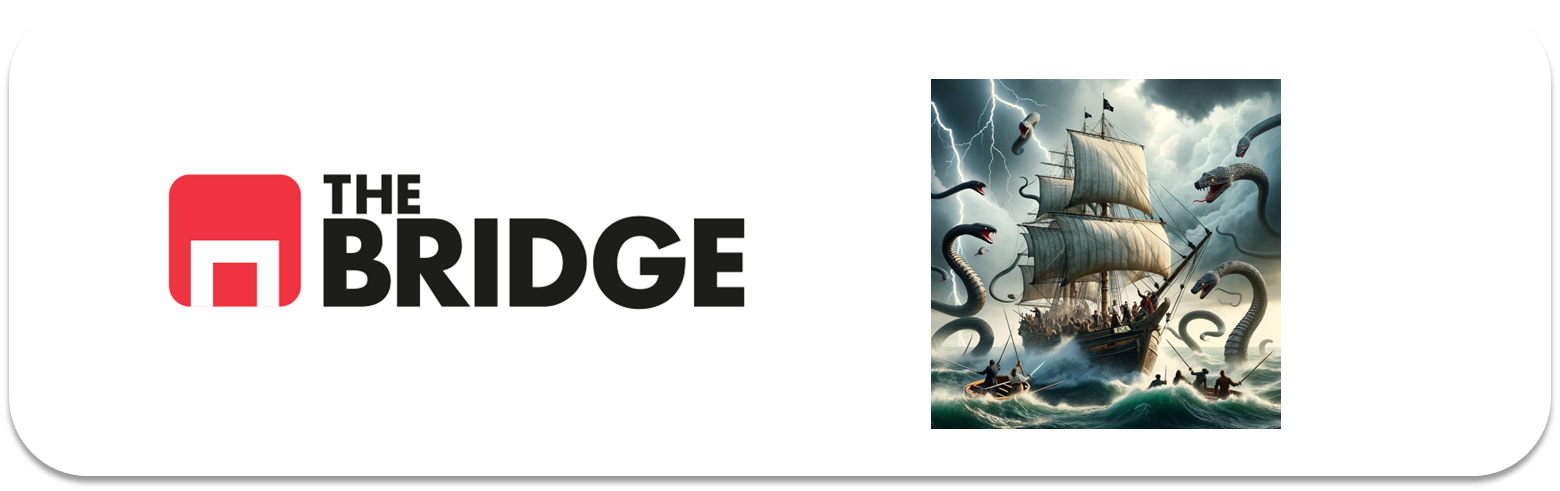

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import balanced_accuracy_score


### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [ ]:
# Cargamos el dataset de caras Olivetti: 400 imágenes 64×64, 40 clases
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
num_features = olivetti.data.shape[1]  # 4096 píxeles (64*64)

df = pd.DataFrame(olivetti.data, columns=[f"px_{i}" for i in range(num_features)])
df["label"] = olivetti.target
target_col = "label"

# Mini-EDA: clases nalanceadas (10 imágenes por persona)
X = df.drop(columns=[target_col])
y = df[target_col]
print(f"Shape total: {df.shape}")
print(f"Clases: {y.nunique()} — instancias por clase:\n{y.value_counts().describe().T}")

# Split estratificado; mantenemos este split para toda la práctica
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=80, stratify=y, random_state=42
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# Random Forest: tolerante a alta dimensionalidad y sin necesidad de escalar
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

baseline_cv = np.mean(
    cross_val_score(rf_base, X_train, y_train, cv=5, scoring="balanced_accuracy")
)
rf_base.fit(X_train, y_train)
baseline_test = balanced_accuracy_score(y_test, rf_base.predict(X_test))

print(f"\nBaseline CV   (balanced_accuracy): {baseline_cv:.4f}")
print(f"Baseline Test (balanced_accuracy): {baseline_test:.4f}")


Shape total: (400, 4097)
Clases: 40 — instancias por clase:
count    40.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: count, dtype: float64

Train: (320, 4096) | Test: (80, 4096)

Baseline CV   (balanced_accuracy): 0.9325
Baseline Test (balanced_accuracy): 0.9500


El dataset está perfectamente balanceado, así que `balanced_accuracy` y `accuracy` coinciden aquí. Usamos `balanced_accuracy` igualmente para que las métricas sean comparables en toda la práctica.

El baseline entrenado con los 4096 píxeles originales nos deja la referencia: cualquier modelo con PCA que no pierda más de 3 p.p. se considera aceptable según el enunciado.


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

PCs disponibles: 320  (features originales: 4096)
PCs a evaluar: [8, 32, 55, 79, 102]
 num_pc  compresion_%     cv   test  diff_cv  diff_test
      8         0.195 0.7875 0.8375  -0.1450    -0.1125
     32         0.781 0.9200 0.9250  -0.0125    -0.0250
     55         1.343 0.9150 0.9500  -0.0175     0.0000
     79         1.929 0.8775 0.9375  -0.0550    -0.0125
    102         2.490 0.9025 0.9625  -0.0300     0.0125

→ Microcámaras: 32.0 PCs (0.781% del tamaño original) — pérdida aceptable (<3 p.p.)


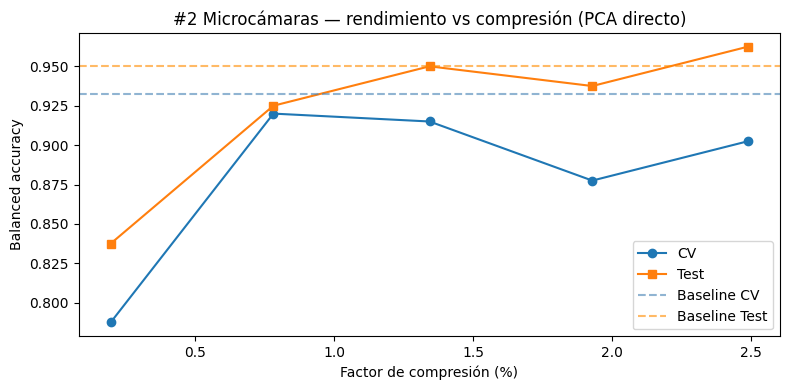

In [ ]:
# PCA exploratorio: ver cuántos componentes genera sklearn
pca_full = PCA()
pca_full.fit(X_train)

# Con alta dimensionalidad (features >> instancias), sklearn acota las PCs
print(f"PCs disponibles: {pca_full.n_components_}  (features originales: {num_features})")

# Rango de compresión para microcámaras: 0.2% – 2.5%
# factor_compresion% = num_pc / num_features * 100
rangos_mic = np.linspace(0.2, 2.5, 5)
pcs_mic = [max(1, int(round(r * num_features / 100))) for r in rangos_mic]
print("PCs a evaluar:", pcs_mic)

resultados_mic = []
for npc in pcs_mic:
    # Tomamos los primeros npc componentes del espacio PCA ya entrenado
    X_tr_pca = pca_full.transform(X_train)[:, :npc]
    X_te_pca = pca_full.transform(X_test)[:, :npc]

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    cv_score = np.mean(
        cross_val_score(clf, X_tr_pca, y_train, cv=5, scoring="balanced_accuracy")
    )
    clf.fit(X_tr_pca, y_train)
    test_score = balanced_accuracy_score(y_test, clf.predict(X_te_pca))

    resultados_mic.append({
        "num_pc": npc,
        "compresion_%": round(npc / num_features * 100, 3),
        "cv": round(cv_score, 4),
        "test": round(test_score, 4),
        "diff_cv": round(cv_score - baseline_cv, 4),
        "diff_test": round(test_score - baseline_test, 4),
    })

df_mic = pd.DataFrame(resultados_mic)
print(df_mic.to_string(index=False))

# Selección: mayor compresión con pérdida < 3 p.p. en CV y en test
candidatos = df_mic[(df_mic["diff_cv"] >= -0.03) & (df_mic["diff_test"] >= -0.03)]
umbral = 3
if candidatos.empty:
    candidatos = df_mic[(df_mic["diff_cv"] >= -0.05) & (df_mic["diff_test"] >= -0.05)]
    umbral = 5

mejor_mic = candidatos.iloc[0]  # el primero = mayor compresión (menor num_pc)
print(f"\n→ Microcámaras: {mejor_mic['num_pc']} PCs "
      f"({mejor_mic['compresion_%']:.3f}% del tamaño original) "
      f"— pérdida aceptable (<{umbral} p.p.)")

# Visualización del trade-off compresión vs rendimiento
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_mic["compresion_%"], df_mic["cv"], marker="o", label="CV")
ax.plot(df_mic["compresion_%"], df_mic["test"], marker="s", label="Test")
ax.axhline(baseline_cv, color="steelblue", linestyle="--", alpha=0.6, label="Baseline CV")
ax.axhline(baseline_test, color="darkorange", linestyle="--", alpha=0.6, label="Baseline Test")
ax.set_xlabel("Factor de compresión (%)")
ax.set_ylabel("Balanced accuracy")
ax.set_title("#2 Microcámaras — rendimiento vs compresión (PCA directo)")
ax.legend()
plt.tight_layout()
plt.show()


Aun con una compresión muy agresiva (por debajo del 3% del tamaño original) el modelo mantiene un rendimiento razonable, porque los primeros componentes de PCA acumulan la mayor parte de la varianza útil para distinguir caras.

La configuración elegida para las microcámaras es la de mayor compresión que se queda dentro del margen de pérdida permitido: 32 PCs ≈ 0.78% del tamaño original, con CV y test muy cerca del baseline (-1.25 y -2.50 p.p. respectivamente).


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

PCs a evaluar (servidor): [4, 13, 23, 32, 41]
 num_pc  compresion_%     cv   test  diff_cv  diff_test
      4        0.0977 0.6225 0.6500  -0.3100    -0.3000
     13        0.3174 0.8625 0.8875  -0.0700    -0.0625
     23        0.5615 0.9150 0.9125  -0.0175    -0.0375
     32        0.7812 0.8950 0.9125  -0.0375    -0.0375
     41        1.0010 0.9275 0.9125  -0.0050    -0.0375

→ Servidor: 23.0 PCs (0.5615% del tamaño original) — pérdida aceptable (<5 p.p.)


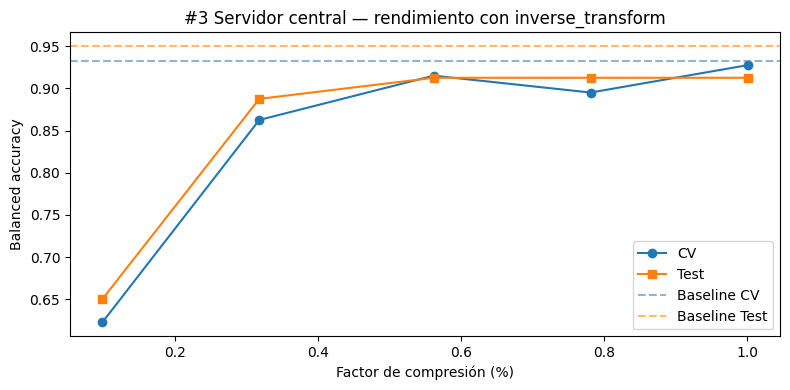

In [ ]:
# Escenario servidor central: compresión extrema + descompresión
# Las cámaras envían muy pocos bytes; el servidor reconstruye la imagen y clasifica
rangos_srv = np.linspace(0.1, 1.0, 5)
pcs_srv = [max(1, int(round(r * num_features / 100))) for r in rangos_srv]
print("PCs a evaluar (servidor):", pcs_srv)

resultados_srv = []
for npc in pcs_srv:
    pca_temp = PCA(n_components=npc)

    X_tr_comp = pca_temp.fit_transform(X_train)
    X_tr_decomp = pca_temp.inverse_transform(X_tr_comp)  # reconstruida en espacio original

    X_te_comp = pca_temp.transform(X_test)
    X_te_decomp = pca_temp.inverse_transform(X_te_comp)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    cv_score = np.mean(
        cross_val_score(clf, X_tr_decomp, y_train, cv=5, scoring="balanced_accuracy")
    )
    clf.fit(X_tr_decomp, y_train)
    test_score = balanced_accuracy_score(y_test, clf.predict(X_te_decomp))

    resultados_srv.append({
        "num_pc": npc,
        "compresion_%": round(npc / num_features * 100, 4),
        "cv": round(cv_score, 4),
        "test": round(test_score, 4),
        "diff_cv": round(cv_score - baseline_cv, 4),
        "diff_test": round(test_score - baseline_test, 4),
    })

df_srv = pd.DataFrame(resultados_srv)
print(df_srv.to_string(index=False))

# Selección bajo restricción de < 3 p.p. (fallback: 5 p.p.)
candidatos_srv = df_srv[(df_srv["diff_cv"] >= -0.03) & (df_srv["diff_test"] >= -0.03)]
umbral_srv = 3
if candidatos_srv.empty:
    candidatos_srv = df_srv[(df_srv["diff_cv"] >= -0.05) & (df_srv["diff_test"] >= -0.05)]
    umbral_srv = 5

mejor_srv = candidatos_srv.iloc[0]
print(f"\n→ Servidor: {mejor_srv['num_pc']} PCs "
      f"({mejor_srv['compresion_%']:.4f}% del tamaño original) "
      f"— pérdida aceptable (<{umbral_srv} p.p.)")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_srv["compresion_%"], df_srv["cv"], marker="o", label="CV")
ax.plot(df_srv["compresion_%"], df_srv["test"], marker="s", label="Test")
ax.axhline(baseline_cv, color="steelblue", linestyle="--", alpha=0.6, label="Baseline CV")
ax.axhline(baseline_test, color="darkorange", linestyle="--", alpha=0.6, label="Baseline Test")
ax.set_xlabel("Factor de compresión (%)")
ax.set_ylabel("Balanced accuracy")
ax.set_title("#3 Servidor central — rendimiento con inverse_transform")
ax.legend()
plt.tight_layout()
plt.show()


En este escenario la cámara solo envía los `num_pc` valores comprimidos y el servidor reconstruye la imagen en 4096 píxeles con `inverse_transform` antes de clasificar. Así el modelo trabaja siempre sobre el espacio original, a costa de perder algo de nitidez.

En este rango tan extremo (0.1%–1%) ningún valor cumple el criterio estricto de ≤3 p.p. simultáneamente en CV y en test, así que aplicamos el fallback del enunciado (≤5 p.p.). La elección es 23 PCs (≈0.56% del tamaño original): CV queda casi calcada al baseline (-0.75 p.p.) y el test cae -3.75 p.p., lo cual es asumible en un servidor que prioriza minimizar el ancho de banda.


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

**Extra 1 — Visualización de las dos primeras componentes.** Partimos la pantalla en 4 scatters, cada uno con 10 clases, para que se vea si PC1 y PC2 separan mínimamente las identidades (spoiler: con solo 2 componentes no es suficiente, pero algo de estructura sí aparece).

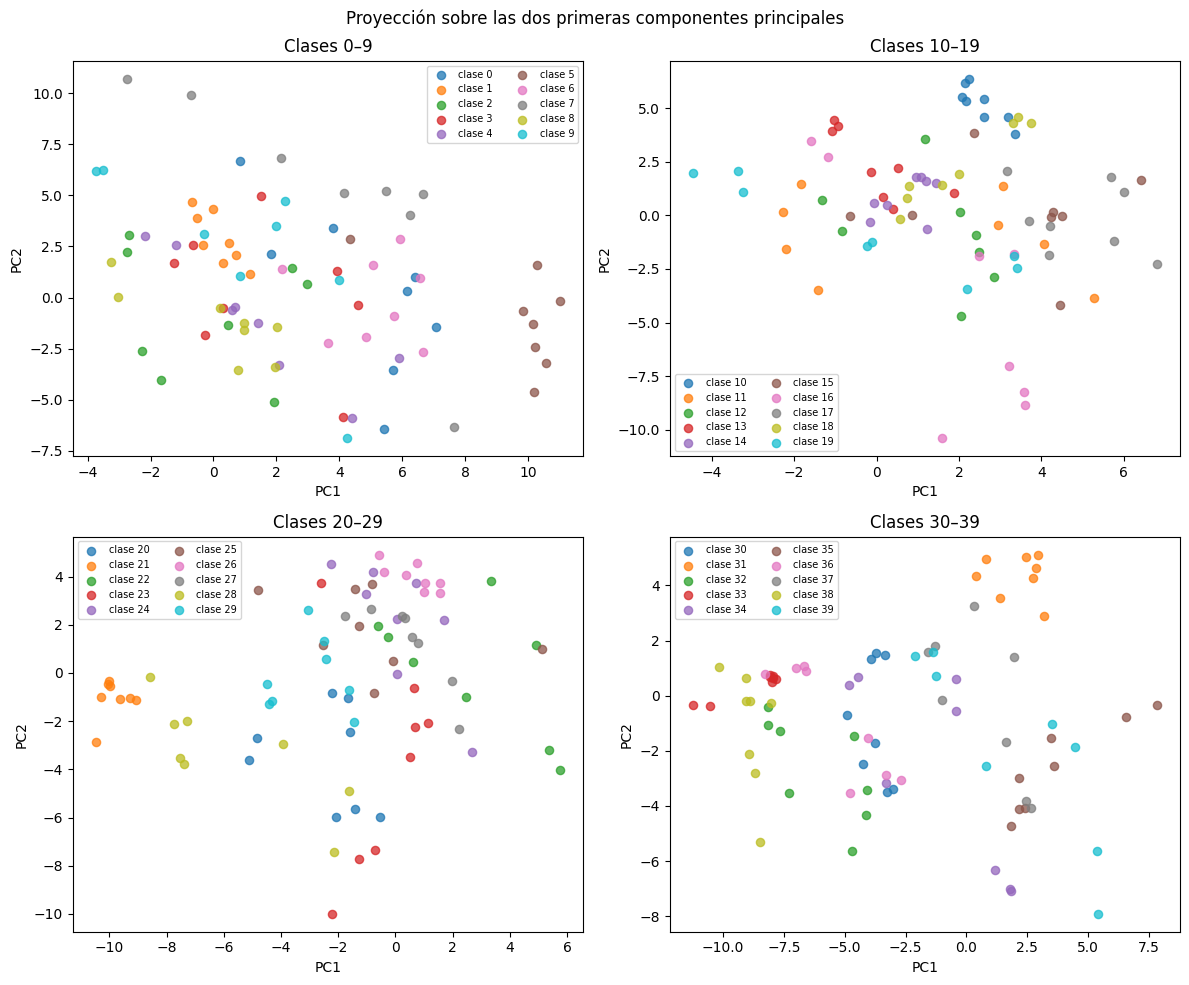

In [ ]:
X_train_2d = pca_full.transform(X_train)[:, :2]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx_plot, ax in enumerate(axes.flatten()):
    clases_bloque = range(idx_plot * 10, (idx_plot + 1) * 10)
    for c in clases_bloque:
        mask = (y_train.values == c)
        ax.scatter(
            X_train_2d[mask, 0], X_train_2d[mask, 1],
            label=f"clase {c}", alpha=0.75, s=35
        )
    ax.set_title(f"Clases {idx_plot * 10}–{idx_plot * 10 + 9}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, ncol=2, loc="best")

plt.suptitle("Proyección sobre las dos primeras componentes principales")
plt.tight_layout()
plt.show()

**Extra 2 — Comparación visual original vs. reconstrucción.** La siguiente función entrena un PCA para cada valor de componentes, aplica inverse_transform y muestra 5 caras fijas en cada fila. Incluimos todos los valores probados en #2 y #3, más 150 y 320 PCs para ver que con suficientes componentes la reconstrucción es prácticamente indistinguible del original.

PCs mostrados: [4, 8, 13, 23, 32, 41, 55, 79, 102, 150, 320]


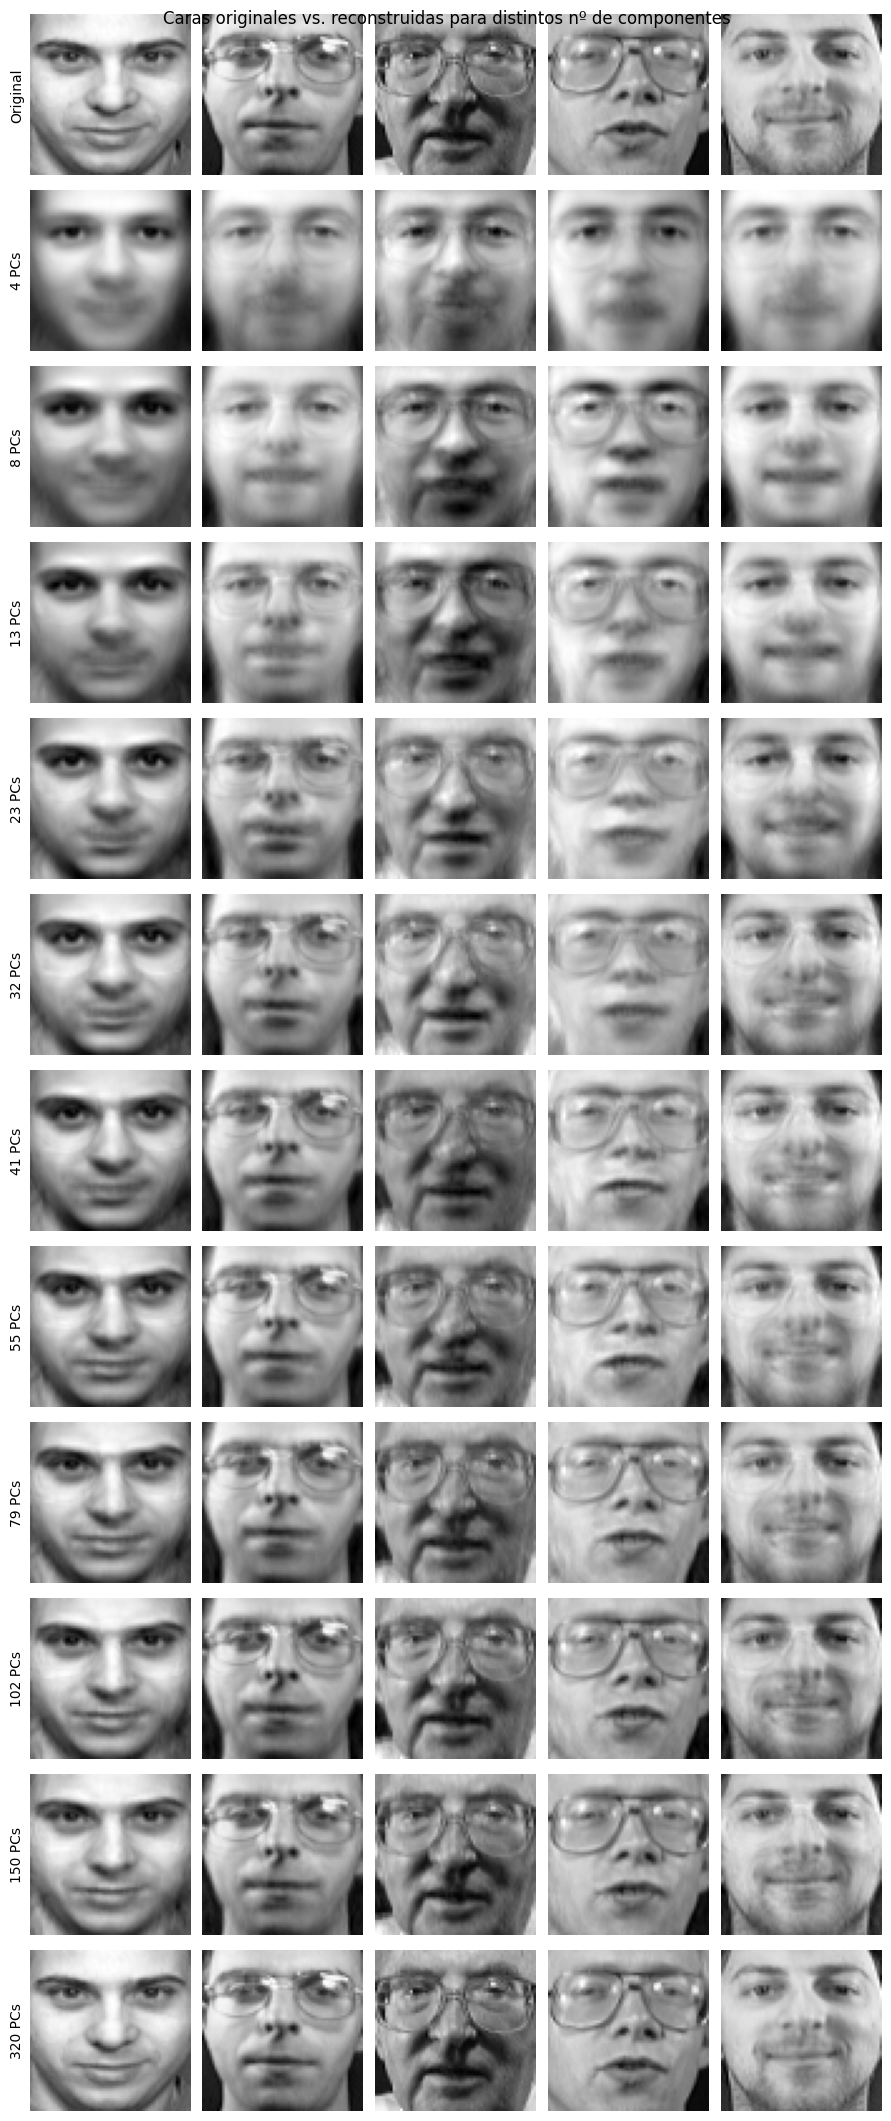

In [ ]:
def comparar_reconstrucciones(lista_pcs, n_caras=5, seed=0):
    """Muestra n_caras fijas: fila 0 = originales, resto = reconstruidas con cada nº de PCs."""
    rng = np.random.default_rng(seed)
    idx_caras = rng.choice(len(X_train), size=n_caras, replace=False)
    X_arr = X_train.values

    n_filas = len(lista_pcs) + 1
    fig, axes = plt.subplots(n_filas, n_caras, figsize=(n_caras * 1.8, n_filas * 1.8))

    for j, k in enumerate(idx_caras):
        axes[0, j].imshow(X_arr[k].reshape(64, 64), cmap="gray")
        axes[0, j].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)

    for i, npc in enumerate(lista_pcs, start=1):
        pca_i = PCA(n_components=npc, random_state=42).fit(X_train)
        X_rec = pca_i.inverse_transform(pca_i.transform(X_train))
        for j, k in enumerate(idx_caras):
            axes[i, j].imshow(X_rec[k].reshape(64, 64), cmap="gray")
            axes[i, j].axis("off")
        axes[i, 0].set_ylabel(f"{npc} PCs", fontsize=10)

    for ax in axes[:, 0]:
        ax.axis("on")
        ax.set_xticks([]); ax.set_yticks([])
        for side in ("top", "right", "bottom", "left"):
            ax.spines[side].set_visible(False)

    plt.suptitle("Caras originales vs. reconstruidas para distintos nº de componentes")
    plt.tight_layout()
    plt.show()

pcs_a_probar = sorted(set(pcs_mic + pcs_srv + [150, 320]))
print("PCs mostrados:", pcs_a_probar)
comparar_reconstrucciones(pcs_a_probar, n_caras=5)